In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [4]:
def quantile_list(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
    
        posterior = np.load(f"em_posteriors/source_{j}/posterior.npz")

        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("log10_mej_dyn")

(array([3., 6., 1., 4., 2., 2., 3., 4., 1., 2.]),
 array([0.        , 0.09420693, 0.18841387, 0.2826208 , 0.37682773,
        0.47103467, 0.5652416 , 0.65944853, 0.75365547, 0.8478624 ,
        0.94206933]),
 <BarContainer object of 10 artists>)

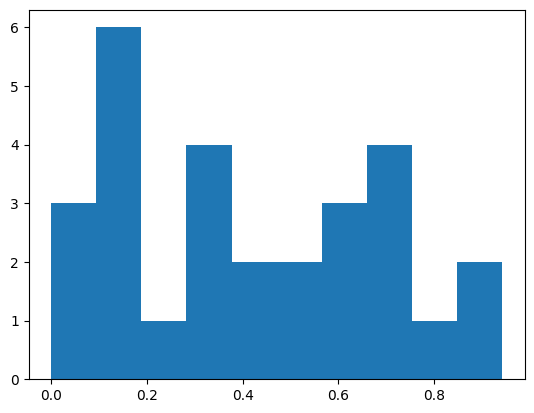

In [5]:
plt.hist(quantiles)

In [6]:
quantiles.argsort()

array([ 0, 12,  5,  7,  3, 23,  8,  9, 19, 26, 14, 27, 16,  1, 21, 20, 13,
       15,  2, 24, 22, 17,  4, 10, 25,  6, 11, 18])

In [7]:
cols = ['log10_mej_dyn', 'v_ej_dyn', 'Ye_dyn', 'log10_mej_wind', 'v_ej_wind', 'Ye_wind', 'inclination_EM']
events.loc[0, cols]

log10_mej_dyn         -inf
v_ej_dyn          0.152297
Ye_dyn            0.328236
log10_mej_wind    -1.56177
v_ej_wind         0.110911
Ye_wind           0.310179
inclination_EM    0.448611
Name: 0, dtype: object

In [8]:
events.loc[12, cols]

log10_mej_dyn         -inf
v_ej_dyn          0.153045
Ye_dyn            0.152278
log10_mej_wind   -1.308572
v_ej_wind         0.128835
Ye_wind           0.240675
inclination_EM    0.758328
Name: 12, dtype: object